<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/cancer_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# A. Load Dataset

dataset = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cancer_coded.csv')

In [ ]:
dataset.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0


In [ ]:
# B. Data Cleaning

new_dataset= dataset.drop('Sample code number', axis=1)
new_dataset


,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
678,3,1,1,1,3,2,1,1,1,0
679,2,1,1,1,2,1,1,1,1,0
680,5,10,10,3,7,3,8,10,2,1
681,4,8,6,4,3,4,10,6,1,1


In [ ]:
# C. Insert a validation data

validation_data = [
    [5, 9, 9, 3, 7, 3, 8, 9, 2, -1],
    [3, 2, 1, 1, 2, 3, 1, 1, 1, -1]
]
validation_df = pd.DataFrame(validation_data, columns=new_dataset.columns)
new_validation_dataset = pd.concat([new_dataset, validation_df], ignore_index=True)
new_validation_dataset

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
680,5,10,10,3,7,3,8,10,2,1
681,4,8,6,4,3,4,10,6,1,1
682,4,8,8,5,4,5,10,4,1,1
683,5,9,9,3,7,3,8,9,2,-1


In [ ]:
# D. Use StandardScaler to normalize the dataset

from sklearn.preprocessing import StandardScaler

features = new_validation_dataset.iloc[:, :-1]
labels = new_validation_dataset.iloc[:, -1]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# New DataFrame with the scaled features and original labels
scaled_dataset = pd.DataFrame(scaled_features, columns=features.columns)
scaled_dataset['Class'] = labels.values

scaled_dataset

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,0.198609,-0.703536,-0.742273,-0.639260,-0.556793,-0.699415,-0.182758,-0.613887,-0.348691,0
1,0.198609,0.274655,0.260601,0.759760,1.692045,1.775840,-0.182758,-0.286640,-0.348691,0
2,-0.511821,-0.703536,-0.742273,-0.639260,-0.556793,-0.424387,-0.182758,-0.613887,-0.348691,0
3,0.553824,1.578909,1.597766,-0.639260,-0.107025,0.125670,-0.182758,1.349595,-0.348691,0
4,-0.156606,-0.703536,-0.742273,0.060250,-0.556793,-0.699415,-0.182758,-0.613887,-0.348691,0
...,...,...,...,...,...,...,...,...,...,...
680,0.198609,2.231036,2.266349,0.060250,1.692045,-0.149358,1.856151,2.331336,0.229646,1
681,-0.156606,1.578909,0.929184,0.410005,-0.107025,0.125670,2.671714,1.022348,-0.348691,1
682,-0.156606,1.578909,1.597766,0.759760,0.342743,0.400698,2.671714,0.367854,-0.348691,1
683,0.198609,1.904972,1.932058,0.060250,1.692045,-0.149358,1.856151,2.004089,0.229646,-1


In [ ]:
# E. Remove the validation data from the dataset before training

train_dataset = new_validation_dataset.iloc[:-2, :]  # all rows except the last two
train_features = train_dataset.iloc[:, :-1]
train_labels = train_dataset.iloc[:, -1]

scaler = StandardScaler()
scaled_train_features = scaler.fit_transform(train_features)

scaled_train_dataset = pd.DataFrame(scaled_train_features, columns=train_features.columns)
scaled_train_dataset['Class'] = train_labels.values

scaled_train_dataset

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,0.197905,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.181827,-0.612927,-0.348400,0
1,0.197905,0.277252,0.262783,0.758032,1.695166,1.772867,-0.181827,-0.285105,-0.348400,0
2,-0.511643,-0.702212,-0.741774,-0.639366,-0.555608,-0.424217,-0.181827,-0.612927,-0.348400,0
3,0.552679,1.583204,1.602192,-0.639366,-0.105454,0.125054,-0.181827,1.354008,-0.348400,0
4,-0.156869,-0.702212,-0.741774,0.059333,-0.555608,-0.698853,-0.181827,-0.612927,-0.348400,0
...,...,...,...,...,...,...,...,...,...,...
678,-0.511643,-0.702212,-0.741774,-0.639366,-0.105454,-0.424217,-0.998853,-0.612927,-0.348400,0
679,-0.866417,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.998853,-0.612927,-0.348400,0
680,0.197905,2.236180,2.271896,0.059333,1.695166,-0.149582,1.860738,2.337476,0.229166,1
681,-0.156869,1.583204,0.932487,0.408682,-0.105454,0.125054,2.677764,1.026185,-0.348400,1


In [ ]:
# F. Train/Test Split is test_size = 0.2, random_state = 101


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    scaled_train_dataset.iloc[:, :-1],
    scaled_train_dataset['Class'],
    test_size=0.2,
    random_state=101
)

In [ ]:
# What is the accuracy of the model based on classification report?


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        95
           1       1.00      0.95      0.98        42

    accuracy                           0.99       137
   macro avg       0.99      0.98      0.98       137
weighted avg       0.99      0.99      0.99       137

Accuracy: 0.9854014598540146


In [ ]:
#	What is the prediction on the 1st validation data? (0 or 1)?
# What is the prediction on the 2nd validation data? (0 or 1?


validation_features = validation_set.iloc[:, :-1]

scaled_validation_features = scaler.transform(validation_features)
scaled_validation_df = pd.DataFrame(scaled_validation_features, columns=validation_features.columns)

validation_predictions = clf.predict(scaled_validation_df)

print("Prediction for 1st validation data:", validation_predictions[0])
print("Prediction for 2nd validation data:", validation_predictions[1])

Prediction for 1st validation data: 1
Prediction for 2nd validation data: 0


           Feature  Coefficient
0  Clump Thickness     1.214382
5      Bare Nuclei     1.077359


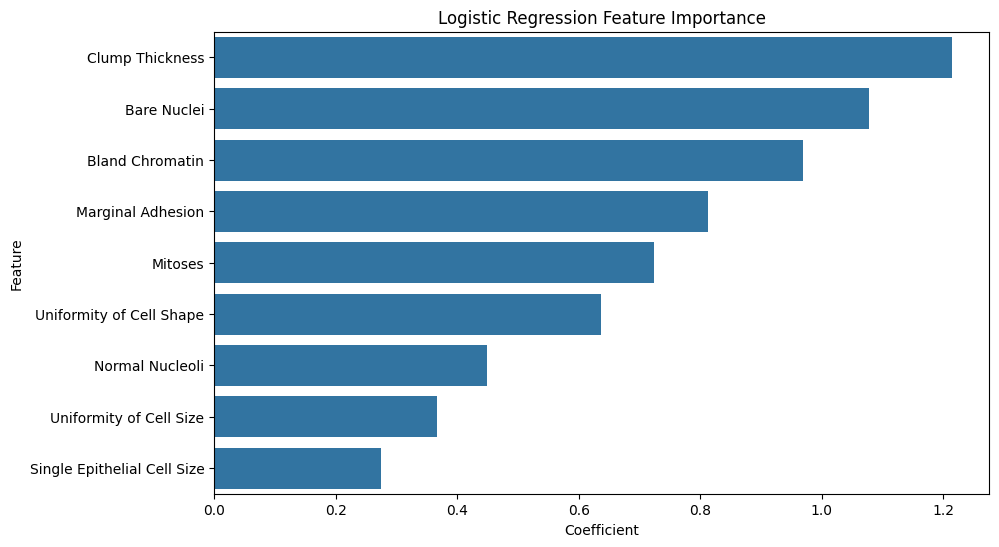

In [ ]:
# Give at least two variables that can highly predict the 'Outcome Predicton' based on Logistics Graphs


feature_names = X_train.columns
coefficients = clf.coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
})

# Sort by absolute value of coefficient (importance)
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df_sorted.head(2))

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df_sorted)
plt.title('Logistic Regression Feature Importance')
plt.show()

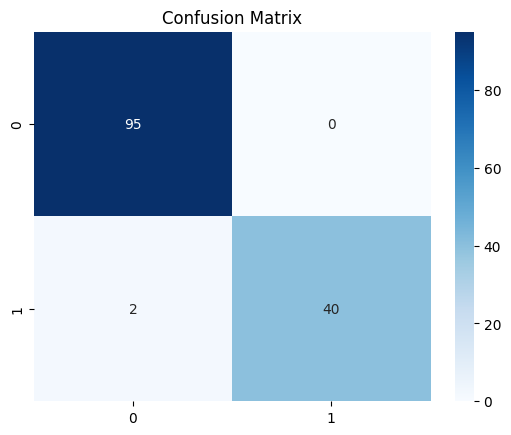

In [ ]:
# Plot the Confusion Matrix

from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')

plt.title('Confusion Matrix')

plt.show()

## Conclusion

The Logistic Regression model demonstrated high accuracy in classifying the cancer dataset, achieving approximately 98.5% accuracy on the test set. The `classification_report` and `confusion_matrix` confirm the model's strong performance, with high precision, recall, and f1-scores for both classes.

The feature importance analysis using the coefficients from the logistic regression model revealed that **'Clump Thickness'** and **'Bare Nuclei'** are the two most significant variables in predicting the 'Class' (outcome).

Finally, the model predicted `1` for the first validation data point and `0` for the second validation data point.